# Importings

In [1]:
import os
import random
import numpy as np
from io import BytesIO

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf

from ipywidgets import widgets

2025-12-26 17:58:50.976581: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-26 17:58:51.012627: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-26 17:58:51.690295: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Helper Functions

In [2]:
def visualize_feature_maps(model, img_path, target_size=(150, 150), max_layers=None):
    """
    Visualize convolutional feature maps of a given image through a CNN model.
    
    Args:
        model: Trained tf.keras model.
        img_path: Path to input image.
        target_size: Resize image to this size before feeding into the model.
        max_layers: Optional, limit the number of layers to visualize.
    """
    
    # Build a model that outputs intermediate representations
    successive_outputs = [layer.output for layer in model.layers]
    visualization_model = tf.keras.models.Model(inputs=model.inputs, outputs=successive_outputs)

    # Prepare the image
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    x = tf.keras.utils.img_to_array(img)
    x = x.reshape((1,) + x.shape)  # shape (1, height, width, 3)

    # Get feature maps
    successive_feature_maps = visualization_model.predict(x)
    layer_names = [layer.name for layer in model.layers]

    for layer_name, feature_map in zip(layer_names, successive_feature_maps):
        if len(feature_map.shape) == 4:  # conv/pool layers only
            n_features = feature_map.shape[-1]   # number of feature maps
            size = feature_map.shape[1]          # width/height of each feature map

            # Create a display grid
            display_grid = np.zeros((size, size * n_features))
            for i in range(n_features):
                fm = feature_map[0, :, :, i]
                fm -= fm.mean()
                fm /= (fm.std() + 1e-6)  # avoid div by zero
                fm *= 64
                fm += 128
                fm = np.clip(fm, 0, 255).astype('uint8')
                display_grid[:, i * size:(i + 1) * size] = fm

            # Plot
            scale = 20. / n_features
            plt.figure(figsize=(scale * n_features, scale))
            plt.title(layer_name)
            plt.grid(False)
            plt.imshow(display_grid, aspect='auto', cmap='viridis')

        if max_layers and layer_names.index(layer_name) + 1 >= max_layers:
            break

In [3]:
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(len(acc))
    
    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
    ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
    ax[0].set_title('Training and validation accuracy')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].legend()
    
    ax[1].plot(epochs, loss, 'bo', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
    ax[1].set_title('Training and validation loss')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    ax[1].legend()
    
    plt.show()

In [4]:
def flower_predict_widget(model, class_names, target_size=(150, 150)):
    """
    Create an upload widget for predicting flower classes with a trained model.
    
    Args:
        model: Trained tf.keras model.
        class_names: List of class names in training order.
        target_size: Size to resize images to before prediction.
    """
    
    # File upload widget
    uploader = widgets.FileUpload(accept="image/*", multiple=True)
    out = widgets.Output()
    
    def file_predict(filename, file, out):
        """Predict flower class from uploaded image."""
        # Load and preprocess
        image = tf.keras.utils.load_img(file, target_size=target_size)
        image = tf.keras.utils.img_to_array(image)
        image = np.expand_dims(image, axis=0) / 255.0  # normalize

        # Predict
        predictions = model.predict(image, verbose=0)[0]
        predicted_class_idx = np.argmax(predictions)
        predicted_class = class_names[predicted_class_idx]
        confidence = predictions[predicted_class_idx]

        # Print result
        with out:
            print(f"{filename} → {predicted_class} ({confidence:.2%} confidence)")

    def on_upload_change(change):
        """Handle uploaded files and run predictions."""
        items = change.new
        for item in items:
            file_jpgdata = BytesIO(item.content)
            file_predict(item.name, file_jpgdata, out)

    # Link widget to handler
    uploader.observe(on_upload_change, names='value')
    
    # Display
    display(uploader, out)


# Preparing Dataset

In [5]:
def return_class_dir(base_dir, splitted_dir):
    splitted_loc = os.path.join(base_dir, splitted_dir)
    splitted_dir_classes = os.listdir(splitted_loc)
    classes = []
    for names in splitted_dir_classes:
        loc = base_dir + '/'+ str(splitted_dir) + '/' + names
        classes.append(loc)
    return classes

In [6]:
base_dir = '/home/samin96/ml_notebooks/cnn_flower_project/dataset'

train_daisy_dir,train_dandelion_dir,train_roses_dir,train_sunflowers_dir,train_tulips_dir = return_class_dir(base_dir, 'train')

In [7]:
train_daisy_dir,train_dandelion_dir,train_roses_dir,train_sunflowers_dir,train_tulips_dir

('/home/samin96/ml_notebooks/cnn_flower_project/dataset/train/daisy',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/train/sunflowers',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/train/roses',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/train/tulips',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/train/dandelion')

In [8]:
val_daisy_dir, val_dandelion_dir, val_roses_dir, val_sunflowers_dir, val_tulips_dir = return_class_dir(base_dir, 'val')

In [9]:
val_daisy_dir, val_dandelion_dir, val_roses_dir, val_sunflowers_dir, val_tulips_dir

('/home/samin96/ml_notebooks/cnn_flower_project/dataset/val/daisy',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/val/sunflowers',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/val/roses',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/val/tulips',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/val/dandelion')

In [10]:
test_daisy_dir,test_dandelion_dir,test_roses_dir,test_sunflowers_dir,test_tulips_dir = return_class_dir(base_dir, 'test')

In [11]:
test_daisy_dir,test_dandelion_dir,test_roses_dir,test_sunflowers_dir,test_tulips_dir

('/home/samin96/ml_notebooks/cnn_flower_project/dataset/test/daisy',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/test/sunflowers',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/test/roses',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/test/tulips',
 '/home/samin96/ml_notebooks/cnn_flower_project/dataset/test/dandelion')

In [12]:
train_daisy_dir_fname = os.listdir(train_daisy_dir)
train_dandelion_dir_fnames = os.listdir(train_dandelion_dir)
train_roses_dir_fnames = os.listdir(train_roses_dir)
train_sunflowers_dir_fnames = os.listdir(train_sunflowers_dir)
train_tulips_dir_fnames = os.listdir(train_tulips_dir)

In [13]:
test_daisy_dir_fname = os.listdir(test_daisy_dir)
test_dandelion_dir_fnames = os.listdir(test_dandelion_dir)
test_roses_dir_fnames = os.listdir(test_roses_dir)
test_sunflowers_dir_fnames = os.listdir(test_sunflowers_dir)
test_tulips_dir_fnames = os.listdir(test_tulips_dir)

In [14]:
val_daisy_dir_fname = os.listdir(val_daisy_dir)
val_dandelion_dir_fnames = os.listdir(val_dandelion_dir)
val_roses_dir_fnames = os.listdir(val_roses_dir)
val_sunflowers_dir_fnames = os.listdir(val_sunflowers_dir)
val_tulips_dir_fnames = os.listdir(val_tulips_dir)

In [15]:
print(f"5 files in train roses subdir: {train_roses_dir_fnames[:5]}")

5 files in train roses subdir: ['3412874275_ca78ee024d_m.jpg', '5731750490_ba3325b7ee_n.jpg', '6690926183_afedba9f15_n.jpg', '8442304572_2fdc9c7547_n.jpg', '1446097778_97149b8362.jpg']


In [16]:
print(f'total training rose images: {len(os.listdir(train_roses_dir))}')
print(f'total training sunflowe images: {len(os.listdir(train_sunflowers_dir))}')
print(f'total training dandelion images: {len(os.listdir(train_dandelion_dir))}')
print(f'total training tulips images: {len(os.listdir(train_tulips_dir))}')
print(f'total training daisy images: {len(os.listdir(train_daisy_dir))}')
print('===================================================================')
print(f'total validation rose images: {len(os.listdir(val_roses_dir))}')
print(f'total validation sunflower images: {len(os.listdir(val_sunflowers_dir))}')
print(f'total validation dandelion images: {len(os.listdir(val_dandelion_dir))}')

total training rose images: 448
total training sunflowe images: 559
total training dandelion images: 489
total training tulips images: 628
total training daisy images: 443
total validation rose images: 96
total validation sunflower images: 119
total validation dandelion images: 104


In [17]:
import pandas as pd

df = pd.read_csv('/home/samin96/ml_notebooks/cnn_flower_project/dataset/train.csv')
images = df['image_path']
type(images)

pandas.core.series.Series

FileNotFoundError: [Errno 2] No such file or directory: '/home/samin96/ml_notebooks/cnn_project/dataset/train/dandelion/5572197407_a0047238a6.jpg'

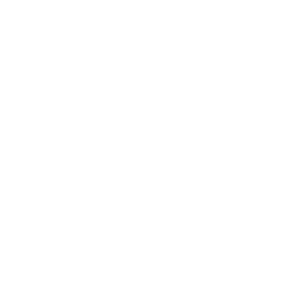

In [18]:
nrows = 4
ncols = 4

fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

flower_pic = random.sample(images.tolist(), k=16)

for i, img_path in enumerate(flower_pic):
    # Set up subplot; subplot indices start at 1
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off') # Don't show axes (or gridlines)

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()



In [ ]:
flower_pic

['/home/samin96/ml_notebooks/cnn_project/dataset/train/sunflowers/18237215308_a158d49f28_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/daisy/144099102_bf63a41e4f_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/dandelion/13881700933_69a750d418_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/sunflowers/3893436870_034b79d118_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/sunflowers/6133988570_9dc778e622_m.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/dandelion/19443726008_8c9c68efa7_m.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/dandelion/5654859907_c2be3b0f1e_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/dandelion/3512879565_88dd8fc269_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/tulips/3511776685_3635087b12_n.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/train/sunflowers/9216286162_6ceefdd1b4_m.jpg',
 '/home/samin96/ml_notebooks/cnn_project/dataset/tr

In [ ]:
from PIL import Image

# Open image
img = Image.open(flower_pic[9])

# Get size: (width, height)
width, height = img.size

print(f"Image size: {width} x {height} pixels")

Image size: 152 x 240 pixels


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    '/home/samin96/ml_notebooks/cnn_project/dataset/train',
    image_size = (150,150),
    batch_size = 20,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    '/home/samin96/ml_notebooks/cnn_project/dataset/val',
    image_size = (150,150),
    batch_size = 20,
    label_mode='categorical'
)

Found 2567 files belonging to 5 classes.
Found 547 files belonging to 5 classes.


2025-09-19 19:58:08.637830: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Building Models

In [ ]:
model0 = tf.keras.models.Sequential([
    # Input + Rescale
    tf.keras.Input(shape=(150, 150, 3)),
    tf.keras.layers.Rescaling(1./255),  # Normalize pixel values to [0,1]

    # Convolutional Blocks
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),


    # Classifier Head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')  # ← 5 classes, softmax
])

In [ ]:
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,496,613 (36.23 MB)

 Trainable params: 9,496,613 (36.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model0.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics = ['accuracy']
    )

In [ ]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset_final = train_dataset.cache().shuffle(SHUFFLE_BUFFER_SIZE).prefetch(PREFETCH_BUFFER_SIZE)
val_dataset_final = val_dataset.cache().prefetch(PREFETCH_BUFFER_SIZE)

In [ ]:
history1 = model0.fit(
    train_dataset_final,
    epochs=15,
    validation_data=val_dataset_final,
    verbose=2
)

Epoch 1/15
129/129 - 9s - 67ms/step - accuracy: 0.4659 - loss: 1.3268 - val_accuracy: 0.4461 - val_loss: 1.2777
Epoch 2/15
129/129 - 8s - 58ms/step - accuracy: 0.5878 - loss: 1.0285 - val_accuracy: 0.5576 - val_loss: 1.0297
Epoch 3/15
129/129 - 7s - 58ms/step - accuracy: 0.6580 - loss: 0.8697 - val_accuracy: 0.6417 - val_loss: 0.9214
Epoch 4/15
129/129 - 7s - 57ms/step - accuracy: 0.7215 - loss: 0.6970 - val_accuracy: 0.6618 - val_loss: 0.8754
Epoch 5/15
129/129 - 7s - 57ms/step - accuracy: 0.7990 - loss: 0.5319 - val_accuracy: 0.6490 - val_loss: 0.9341
Epoch 6/15
129/129 - 7s - 57ms/step - accuracy: 0.8629 - loss: 0.3798 - val_accuracy: 0.6563 - val_loss: 1.0005
Epoch 7/15
129/129 - 7s - 57ms/step - accuracy: 0.9198 - loss: 0.2309 - val_accuracy: 0.6252 - val_loss: 1.4799
Epoch 8/15
129/129 - 7s - 57ms/step - accuracy: 0.9509 - loss: 0.1461 - val_accuracy: 0.6728 - val_loss: 1.4062
Epoch 9/15
129/129 - 7s - 57ms/step - accuracy: 0.9696 - loss: 0.1032 - val_accuracy: 0.6417 - val_loss:

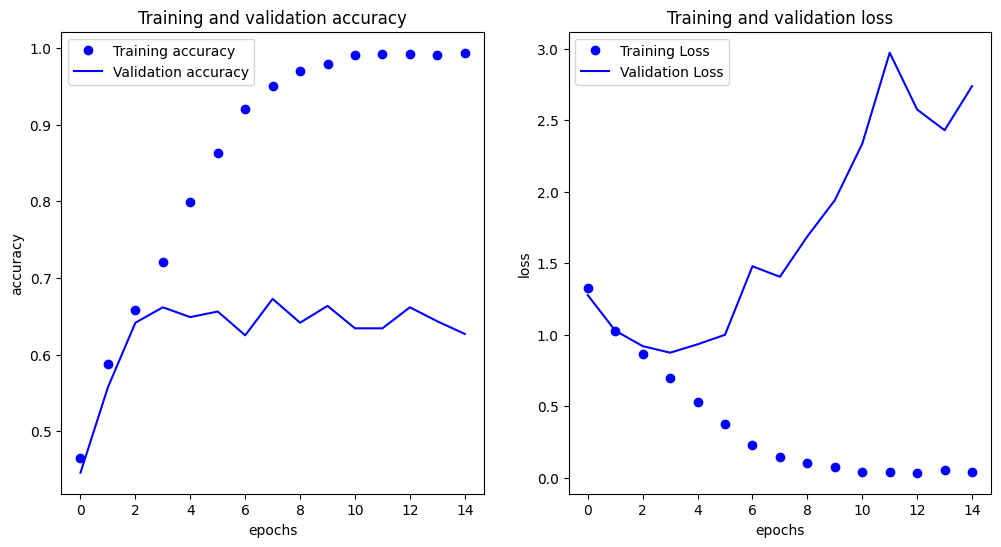

In [ ]:
plot_loss_acc(history1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


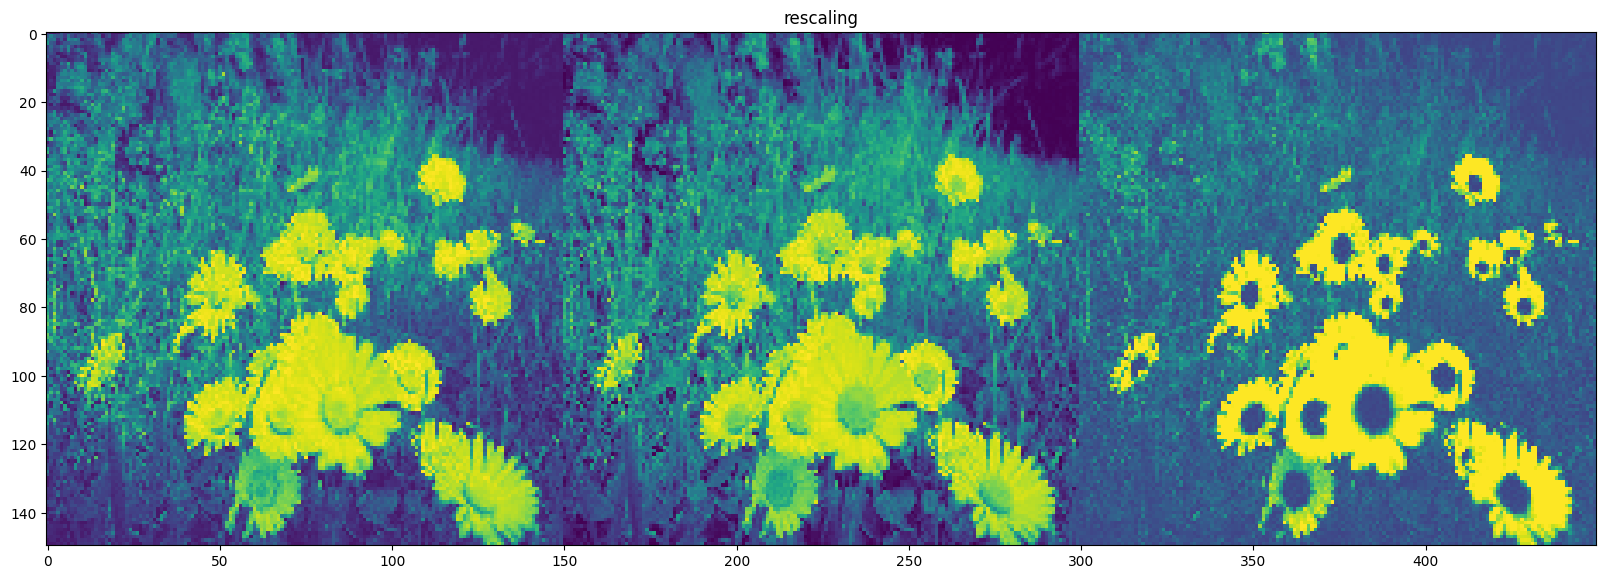

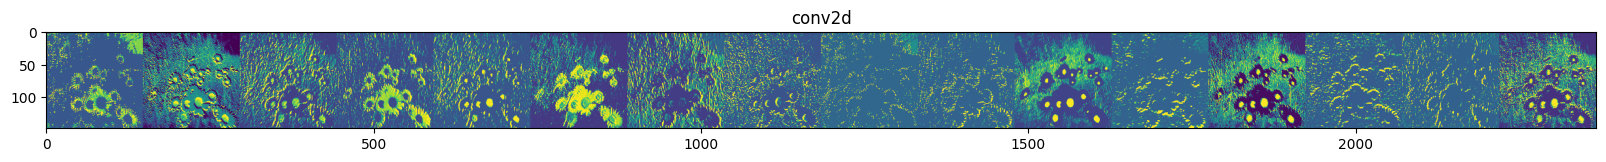

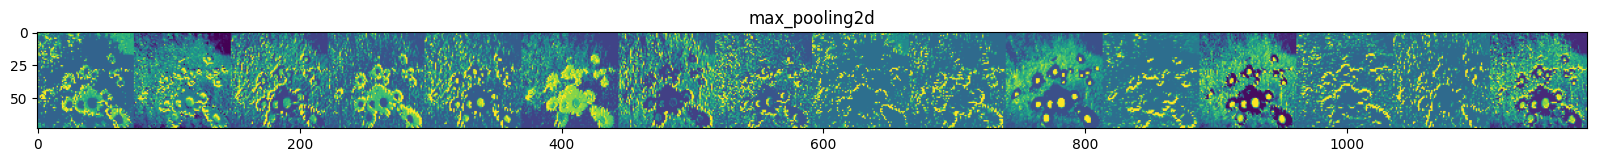

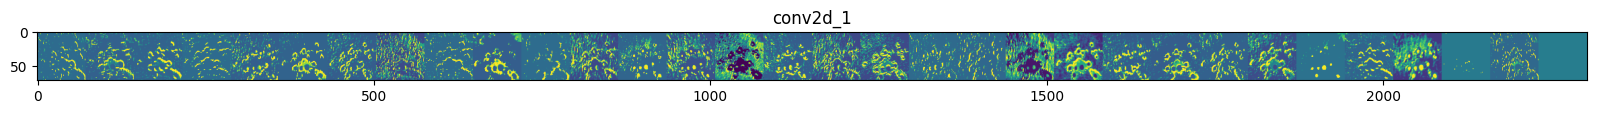

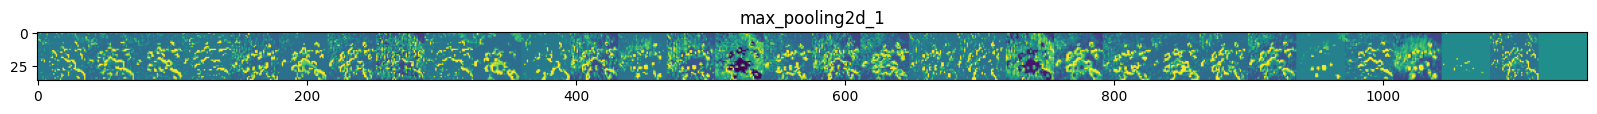

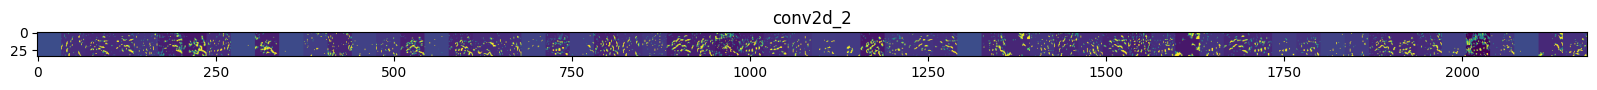

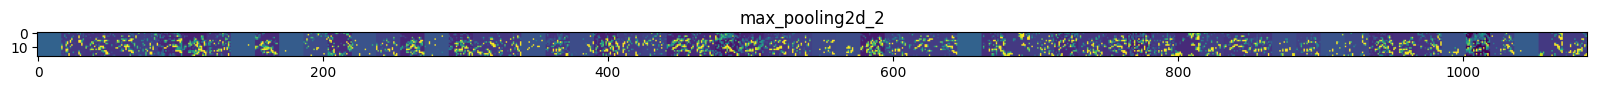

In [ ]:
visualize_feature_maps(model0, random.choice(flower_pic))

In [ ]:
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
flower_predict_widget(model0, class_names)

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Output()

# Transfer Learning

In [ ]:
# Set the weights file you downloaded into a variable
local_weights_file = '/home/samin96/coursera/Tensorflow/model/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Initialize the base model.
# Set the input shape and remove the dense layers.
pre_trained_model = tf.keras.applications.inception_v3.InceptionV3(
    input_shape = (150, 150, 3),
    include_top = False,
    weights = None)

# Load the pre-trained weights you downloaded.
pre_trained_model.load_weights(local_weights_file)

# Freeze the weights of the layers.
for layer in pre_trained_model.layers:
    layer.trainable = False

In [ ]:
#pre_trained_model.summary()

In [ ]:
# Choose `mixed7` as the last layer of your base model
last_layer = pre_trained_model.get_layer('mixed7')
print('last layer output shape: ', last_layer.output.shape)
last_output = last_layer.output

last layer output shape:  (None, 7, 7, 768)


In [ ]:
# Flatten the output layer to 1 dimension
x = tf.keras.layers.Flatten()(last_output)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = tf.keras.layers.Dense(1024, activation='relu')(x)
# Add a dropout rate of 0.2
x = tf.keras.layers.Dropout(0.2)(x)
# Add a final sigmoid layer for classification
x = tf.keras.layers.Dense(5, activation='sigmoid')(x)

# Append the dense network to the base model
model = tf.keras.Model(pre_trained_model.input, x)

# Print the model summary. See your dense network connected at the end.
#model.summary()

In [ ]:
# Define the preprocess function
def preprocess(image, label):
    image = tf.keras.applications.inception_v3.preprocess_input(image)
    return image, label

# Apply the preprocessing to the datasets
train_dataset_scaled = train_dataset.map(preprocess)
val_dataset_scaled = val_dataset.map(preprocess)

In [ ]:
# Optimize the datasets for training
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset_final = (train_dataset_scaled
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(PREFETCH_BUFFER_SIZE)
                       )

val_dataset_final = (val_dataset_scaled
                            .cache()
                            .prefetch(PREFETCH_BUFFER_SIZE)
                            )

### Data Augmentation

In [ ]:
# Create a model with data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.4),
    tf.keras.layers.RandomTranslation(0.2,0.2),
    tf.keras.layers.RandomContrast(0.4),
    tf.keras.layers.RandomZoom(0.2),
    ])

In [ ]:
# Attach the data augmentation model to the base model
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = model(x)

model_with_aug = tf.keras.Model(inputs, x)

In [ ]:
# Set the training parameters
model_with_aug.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'])

In [ ]:
model_with_aug.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 5)              │    47,516,581 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,516,581 (181.26 MB)

 Trainable params: 38,541,317 (147.02 MB)

 Non-trainable params: 8,975,264 (34.24 MB)

In [ ]:
EPOCHS = 20

# Train the model.
history2 = model_with_aug.fit(
    train_dataset_final,
    validation_data = val_dataset_final,
    epochs = EPOCHS,
    verbose = 2)

Epoch 1/20
129/129 - 30s - 229ms/step - accuracy: 0.6128 - loss: 1.0788 - val_accuracy: 0.7733 - val_loss: 0.6496
Epoch 2/20
129/129 - 26s - 203ms/step - accuracy: 0.7074 - loss: 0.7964 - val_accuracy: 0.7971 - val_loss: 0.5511
Epoch 3/20
129/129 - 26s - 203ms/step - accuracy: 0.7460 - loss: 0.7204 - val_accuracy: 0.7477 - val_loss: 0.7813
Epoch 4/20
129/129 - 26s - 203ms/step - accuracy: 0.7507 - loss: 0.6725 - val_accuracy: 0.8227 - val_loss: 0.5187
Epoch 5/20
129/129 - 26s - 203ms/step - accuracy: 0.7760 - loss: 0.6337 - val_accuracy: 0.8080 - val_loss: 0.5406
Epoch 6/20
129/129 - 26s - 203ms/step - accuracy: 0.7885 - loss: 0.6029 - val_accuracy: 0.8026 - val_loss: 0.5823
Epoch 7/20
129/129 - 26s - 203ms/step - accuracy: 0.7780 - loss: 0.5947 - val_accuracy: 0.8300 - val_loss: 0.5579
Epoch 8/20
129/129 - 26s - 203ms/step - accuracy: 0.7861 - loss: 0.5959 - val_accuracy: 0.8373 - val_loss: 0.5378
Epoch 9/20
129/129 - 26s - 203ms/step - accuracy: 0.8002 - loss: 0.5638 - val_accuracy: 

In [ ]:
# model_with_aug.save('/home/samin96/ml_notebooks/cnn_project/artifacts/models/transfer_augmented.h5')

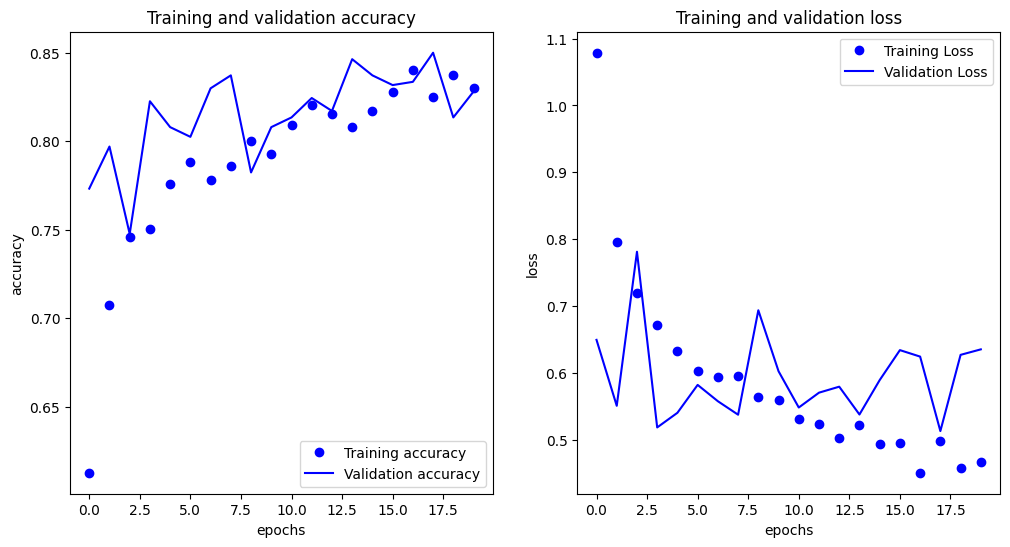

In [ ]:
plot_loss_acc(history2)

In [ ]:
# import pickle

# with open('/home/samin96/ml_notebooks/cnn_project/artifacts/history/augmented_history.pkl', 'wb') as f:
#     pickle.dump(history2.history, f)

In [ ]:
flower_predict_widget(model_with_aug, class_names)

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Output()

# Pretrained model on non augmented data

In [ ]:
# Set the training parameters
model.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'])

In [ ]:
EPOCHS = 20

# Train the model.
history3 = model.fit(
    train_dataset_final,
    validation_data = val_dataset_final,
    epochs = EPOCHS,
    verbose = 2)

Epoch 1/20
129/129 - 28s - 217ms/step - accuracy: 0.8901 - loss: 0.3262 - val_accuracy: 0.8720 - val_loss: 0.4399
Epoch 2/20
129/129 - 26s - 198ms/step - accuracy: 0.9630 - loss: 0.1140 - val_accuracy: 0.8665 - val_loss: 0.5037
Epoch 3/20
129/129 - 26s - 203ms/step - accuracy: 0.9883 - loss: 0.0411 - val_accuracy: 0.8739 - val_loss: 0.5558
Epoch 4/20
129/129 - 26s - 201ms/step - accuracy: 0.9969 - loss: 0.0158 - val_accuracy: 0.8647 - val_loss: 0.5515
Epoch 5/20
129/129 - 41s - 316ms/step - accuracy: 0.9992 - loss: 0.0094 - val_accuracy: 0.8611 - val_loss: 0.5805
Epoch 6/20
129/129 - 26s - 200ms/step - accuracy: 0.9996 - loss: 0.0054 - val_accuracy: 0.8702 - val_loss: 0.5488
Epoch 7/20
129/129 - 26s - 200ms/step - accuracy: 0.9988 - loss: 0.0057 - val_accuracy: 0.8720 - val_loss: 0.5903
Epoch 8/20
129/129 - 26s - 200ms/step - accuracy: 0.9996 - loss: 0.0039 - val_accuracy: 0.8739 - val_loss: 0.5937
Epoch 9/20
129/129 - 26s - 200ms/step - accuracy: 0.9992 - loss: 0.0063 - val_accuracy: 

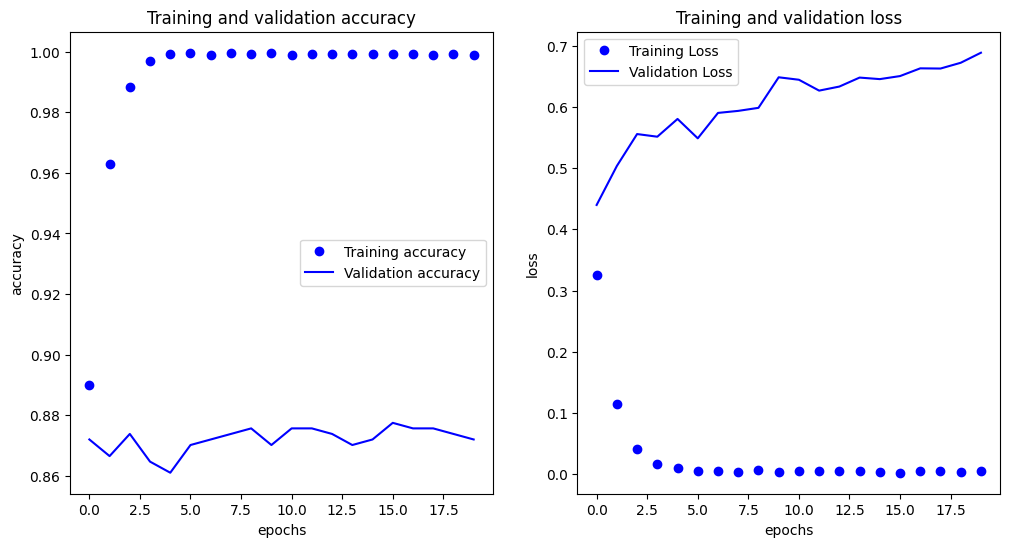

In [ ]:
plot_loss_acc(history3)

In [ ]:
# model.save('/home/samin96/ml_notebooks/cnn_project/artifacts/models/transfer_non_augmented.h5')

In [ ]:
# with open('/home/samin96/ml_notebooks/cnn_project/artifacts/history/non_augmented_history.pkl', 'wb') as f:
#     pickle.dump(history3.history, f)

In [ ]:
flower_predict_widget(model, class_names)

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Output()

In [ ]:
# visualize_feature_maps(model, random.choice(flower_pic))

In [ ]:
# modelx = tf.keras.models.load_model("/home/samin96/ml_notebooks/cnn_project/artifacts/models/transfer_non_augmented.h5")
# flower_predict_widget(modelx, class_names)